<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/age_gender_revised_UTK_face_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [4]:
import os
import zipfile

# List contents of the downloaded path
print("Contents of the dataset directory:")
for item in os.listdir(path):
    print(os.path.join(path, item))

Contents of the dataset directory:
/kaggle/input/utkface-new/UTKFace
/kaggle/input/utkface-new/utkface_aligned_cropped
/kaggle/input/utkface-new/crop_part1


Based on the output, the dataset seems to be already loaded as directories, so no extraction is necessary. Let's inspect the contents of the main `UTKFace` directory.

In [5]:
# The dataset appears to be already downloaded and unzipped into a directory.
# Let's check the contents of the main dataset directory, 'UTKFace'.

dataset_main_path = os.path.join(path, 'UTKFace')

print(f"Contents of the main dataset directory ({dataset_main_path}):")

# List only the first few items to avoid excessive output if there are many files
items = os.listdir(dataset_main_path)
for i, item in enumerate(items):
    if i < 10: # Print only the first 10 items
        print(os.path.join(dataset_main_path, item))
    else:
        print(f"... and {len(items) - 10} more items.")
        break


Contents of the main dataset directory (/kaggle/input/utkface-new/UTKFace):
/kaggle/input/utkface-new/UTKFace/26_0_2_20170104023102422.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/44_0_3_20170119201022260.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/35_0_2_20170116182734834.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/76_0_0_20170104213515132.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/36_1_0_20170116165722892.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/34_0_3_20170119200815948.jpg.chip.jpg
... and 23698 more items.


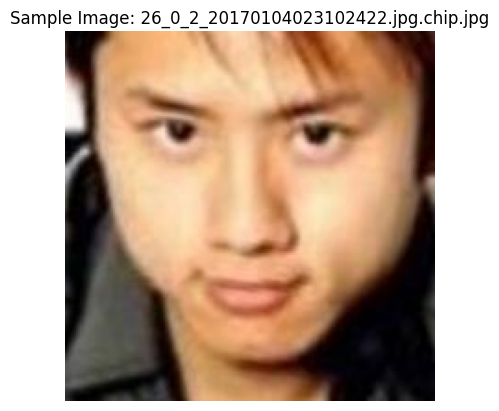

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Get a list of all files in the UTKFace directory
image_files = [f for f in os.listdir(dataset_main_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

if image_files:
    # Select the first image file
    sample_image_name = image_files[0]
    sample_image_path = os.path.join(dataset_main_path, sample_image_name)

    # Load and display the image
    try:
        img = Image.open(sample_image_path)
        plt.imshow(img)
        plt.title(f"Sample Image: {sample_image_name}")
        plt.axis('off') # Hide axes ticks and labels
        plt.show()
    except Exception as e:
        print(f"Error loading or displaying image {sample_image_name}: {e}")
else:
    print("No image files found in the directory.")

In [49]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [8]:
import os

# Ensure 'path' is defined (from previous cells, if not executed)
# For robustness, if 'path' somehow isn't defined here, we'll use a default or re-evaluate.
# Assuming `path` is defined from `Rzwdbcnm_mBs` as '/kaggle/input/utkface-new'.

dataset_main_path = os.path.join(path, 'UTKFace')
folder_path = dataset_main_path
print(f"folder_path is now set to: {folder_path}")

folder_path is now set to: /kaggle/input/utkface-new/UTKFace


In [9]:
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(os.path.join(folder_path,file))



In [10]:
len(age)

23708

In [11]:
df=pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [12]:
df.head()

,age,gender,img
0,26,0,/kaggle/input/utkface-new/UTKFace/26_0_2_20170...
1,22,1,/kaggle/input/utkface-new/UTKFace/22_1_1_20170...
2,21,1,/kaggle/input/utkface-new/UTKFace/21_1_3_20170...
3,28,0,/kaggle/input/utkface-new/UTKFace/28_0_0_20170...
4,17,1,/kaggle/input/utkface-new/UTKFace/17_1_4_20170...


In [13]:
train_df=df.sample(frac=1,random_state=0).iloc[:20000]
test_df=df.sample(frac=1,random_state=0).iloc[20000:]

In [14]:

test_df.shape

(3708, 3)

In [16]:
train_dataegn=ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_dataegn=ImageDataGenerator(rescale=1./255)

In [50]:
class CustomDataSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, datagen, folder_path, target_size=(200, 200), batch_size=32, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.datagen = datagen
        self.folder_path = folder_path
        self.target_size = target_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        batch_df = self.dataframe.iloc[start_idx:end_idx]

        x_batch_list = []
        age_labels_list = []
        gender_labels_list = []

        for _, row in batch_df.iterrows():
            img_path = row['img']
            age = row['age']
            gender = row['gender']

            # Load image
            img = load_img(img_path, target_size=self.target_size)
            img = img_to_array(img)

            # Apply augmentation and standardization
            if self.datagen:
                img = self.datagen.random_transform(img)
                img = self.datagen.standardize(img)

            x_batch_list.append(img)
            age_labels_list.append(age)
            gender_labels_list.append(gender)

        # Explicitly convert to TensorFlow tensors
        x_batch = tf.convert_to_tensor(np.array(x_batch_list), dtype=tf.float32)
        age_labels = tf.convert_to_tensor(np.array(age_labels_list, dtype=np.float32)[:, np.newaxis], dtype=tf.float32) # Reshape to (batch_size, 1)
        gender_labels = tf.convert_to_tensor(np.array(gender_labels_list, dtype=np.float32)[:, np.newaxis], dtype=tf.float32) # Reshape to (batch_size, 1)

        return x_batch, {
            'age_output': age_labels,
            'gender_output': gender_labels
        }

    def on_epoch_end(self):
        if self.shuffle:
            self.dataframe = self.dataframe.sample(frac=1).reset_index(drop=True)

# Instantiate the custom sequence generators
train_generator = CustomDataSequence(train_df, train_dataegn, folder_path, batch_size=32, shuffle=True)

In [51]:
class CustomDataSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, datagen, folder_path, target_size=(200, 200), batch_size=32, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.datagen = datagen
        self.folder_path = folder_path
        self.target_size = target_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        batch_df = self.dataframe.iloc[start_idx:end_idx]

        x_batch_list = []
        age_labels_list = []
        gender_labels_list = []

        for _, row in batch_df.iterrows():
            img_path = row['img']
            age = row['age']
            gender = row['gender']

            # Load image
            img = load_img(img_path, target_size=self.target_size)
            img = img_to_array(img)

            # Apply augmentation and standardization
            if self.datagen:
                img = self.datagen.random_transform(img)
                img = self.datagen.standardize(img)

            x_batch_list.append(img)
            age_labels_list.append(age)
            gender_labels_list.append(gender)

        # Explicitly convert to TensorFlow tensors
        x_batch = tf.convert_to_tensor(np.array(x_batch_list), dtype=tf.float32)
        age_labels = tf.convert_to_tensor(np.array(age_labels_list, dtype=np.float32)[:, np.newaxis], dtype=tf.float32) # Reshape to (batch_size, 1)
        gender_labels = tf.convert_to_tensor(np.array(gender_labels_list, dtype=np.float32)[:, np.newaxis], dtype=tf.float32) # Reshape to (batch_size, 1)

        return x_batch, {
            'age_output': age_labels,
            'gender_output': gender_labels
        }

    def on_epoch_end(self):
        if self.shuffle:
            self.dataframe = self.dataframe.sample(frac=1).reset_index(drop=True)

# Instantiate the custom sequence generators
test_generator = CustomDataSequence(test_df, test_dataegn, folder_path, batch_size=32, shuffle=False)

In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

In [22]:
vgg_net=VGG16(include_top=False,input_shape=(200,200,3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [23]:
vgg_net.trainable=False

In [24]:
x = vgg_net.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)

# Output layer for age (regression)
age_output = Dense(1, activation='linear', name='age_output')(x)

# Output layer for gender (binary classification)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(x)

model = Model(inputs=vgg_net.input, outputs=[age_output, gender_output])

In [25]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss={'age_output': 'mae', 'gender_output': 'binary_crossentropy'},
              metrics={'age_output': 'mae', 'gender_output': 'accuracy'})

In [53]:
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

ModuleNotFoundError: No module named 'keras.utils.vis_utils'